<a href="https://colab.research.google.com/github/marygizem/-Machine-Learning-and-Predictive-Analytics/blob/main/Updated_Milestone_2_Project_Forecasting_Model_with_DataViz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Forecasting Model with Data Visualization

This project develops a machine learning-based forecasting model using historical transaction data. The workflow includes data preprocessing, feature engineering, exploratory analysis, model comparison, and future sales forecasting.

The goal is to predict future monthly sales and support business decision-making through data-driven insights.

In [158]:

import pandas as pd
import matplotlib.pyplot as plt


In [159]:
# Load dataset
merged_data = pd.read_csv("merged_data.csv")

print("DATA LOADED SUCCESSFULLY")
print(merged_data.head())

DATA LOADED SUCCESSFULLY
   Transaction_ID  Company_ID  Product_ID  Quantity Transaction_Date  \
0             2.0        29.0        19.0      16.0       2021-02-21   
1             5.0        47.0         3.0       8.0       2021-02-21   
2             6.0        80.0        11.0       4.0       2021-07-12   
3             8.0        21.0        20.0       7.0       2021-02-21   
4            10.0         3.0        20.0       6.0       2021-02-21   

   Product_Price_x  Total_Cost            Company_Name  Company_Profit  \
0     97930.993380   1428000.0     Sky  Industries  29         61952.0   
1     99575.609634    705600.0   Green  Industries  47         31130.0   
2    160658.675350    627200.0     Green  Partners  80        111227.0   
3    229217.941468   1792000.0  Dynamic Enterprises 21             NaN   
4    238293.851303   1120000.0    Quantum Associates 3        110664.0   

                                             Address  \
0              Edsa, brgy. 606, makati, p

In [160]:
merged_data["Transaction_Date"] = pd.to_datetime(merged_data["Transaction_Date"])


In [161]:
merged_data["YearMonth"] = merged_data["Transaction_Date"].dt.to_period("M").astype(str)


In [162]:
print(merged_data.columns)

Index(['Transaction_ID', 'Company_ID', 'Product_ID', 'Quantity',
       'Transaction_Date', 'Product_Price_x', 'Total_Cost', 'Company_Name',
       'Company_Profit', 'Address', 'Product_Name', 'Product_Price_y',
       'YearMonth'],
      dtype='object')


## Monthly Sales Aggregation

The dataset was aggregated into monthly sales to transform transactional data into a time-series format. This allows the model to analyze trends over time and prepare the data for forecasting.

Key metrics computed include:
- Total sales per month
- Total quantity sold
- Average product price
- Number of transactions

In [163]:
monthly_sales = merged_data.groupby("YearMonth").agg(
    total_sales=("Total_Cost", "sum"),
    total_quantity=("Quantity", "sum"),
    avg_price=("Product_Price_x", "mean"),
    transaction_count=("Transaction_ID", "count")
).reset_index()

print("\nMONTHLY SALES AGGREGATION")
print(monthly_sales.head())
print("Shape:", monthly_sales.shape)


MONTHLY SALES AGGREGATION
  YearMonth   total_sales  total_quantity      avg_price  transaction_count
0   2020-10  4.849600e+06            32.0  148327.692927                  3
1   2020-11  4.777360e+07           368.0  136653.572830                 33
2   2020-12  2.880640e+07           204.0  136438.763122                 21
3   2021-01  4.709600e+07           347.0  137383.563346                 35
4   2021-02  5.694074e+09         41954.0  135119.607704               3999
Shape: (49, 5)


In [164]:
monthly_sales["YearMonth"] = pd.to_datetime(monthly_sales["YearMonth"])


In [165]:
monthly_sales = monthly_sales.sort_values("YearMonth")


## Visualization

This chart shows the monthly sales trend over time. It helps identify patterns such as growth, decline, or seasonality in the data.

Visualizing the data is important to understand how sales behave before building forecasting models.

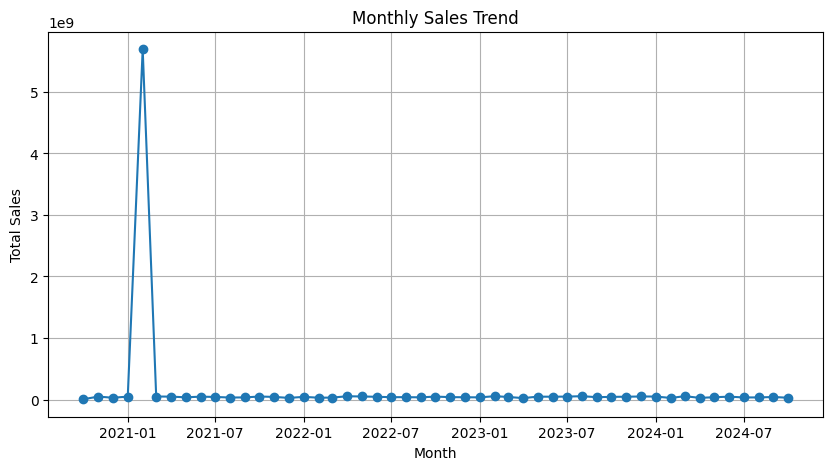

In [166]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales["YearMonth"], monthly_sales["total_sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

## Feature Engineering

New features were created to improve forecasting accuracy. These include:

- Time-based features (month and quarter)
- Lag features (previous sales values)
- Rolling average (moving average of past sales)

These features allow the model to learn patterns from past behavior and improve prediction performance.

In [167]:
# ===============================
# FEATURE ENGINEERING
# ===============================

monthly_sales["YearMonth"] = pd.to_datetime(monthly_sales["YearMonth"])

# Time-based features
monthly_sales["month"] = monthly_sales["YearMonth"].dt.month
monthly_sales["quarter"] = monthly_sales["YearMonth"].dt.quarter

# Lag features
monthly_sales["lag_1"] = monthly_sales["total_sales"].shift(1)
monthly_sales["lag_2"] = monthly_sales["total_sales"].shift(2)
monthly_sales["lag_3"] = monthly_sales["total_sales"].shift(3)

# Rolling feature
monthly_sales["rolling_3"] = monthly_sales["total_sales"].rolling(3).mean()

# Drop rows with null values caused by lag/rolling
monthly_sales = monthly_sales.dropna().reset_index(drop=True)

print("FEATURE ENGINEERING OUTPUT")
print(monthly_sales.head())
print("Shape:", monthly_sales.shape)

FEATURE ENGINEERING OUTPUT
   YearMonth   total_sales  total_quantity      avg_price  transaction_count  \
0 2021-01-01  4.709600e+07           347.0  137383.563346                 35   
1 2021-02-01  5.694074e+09         41954.0  135119.607704               3999   
2 2021-03-01  4.901680e+07           385.0  126132.230470                 37   
3 2021-04-01  4.713520e+07           370.0  126509.331814                 32   
4 2021-05-01  3.565520e+07           278.0  128247.636309                 27   

   month  quarter         lag_1         lag_2         lag_3     rolling_3  
0      1        1  2.880640e+07  4.777360e+07  4.849600e+06  4.122533e+07  
1      2        1  4.709600e+07  2.880640e+07  4.777360e+07  1.923326e+09  
2      3        1  5.694074e+09  4.709600e+07  2.880640e+07  1.930062e+09  
3      4        2  4.901680e+07  5.694074e+09  4.709600e+07  1.930075e+09  
4      5        2  4.713520e+07  4.901680e+07  5.694074e+09  4.393573e+07  
Shape: (46, 11)


## Correlation Analysis

A correlation heatmap was generated to examine relationships between features. This helps identify which variables are strongly related to total sales and useful for prediction.

Lag features and rolling averages are expected to show strong correlation with sales.

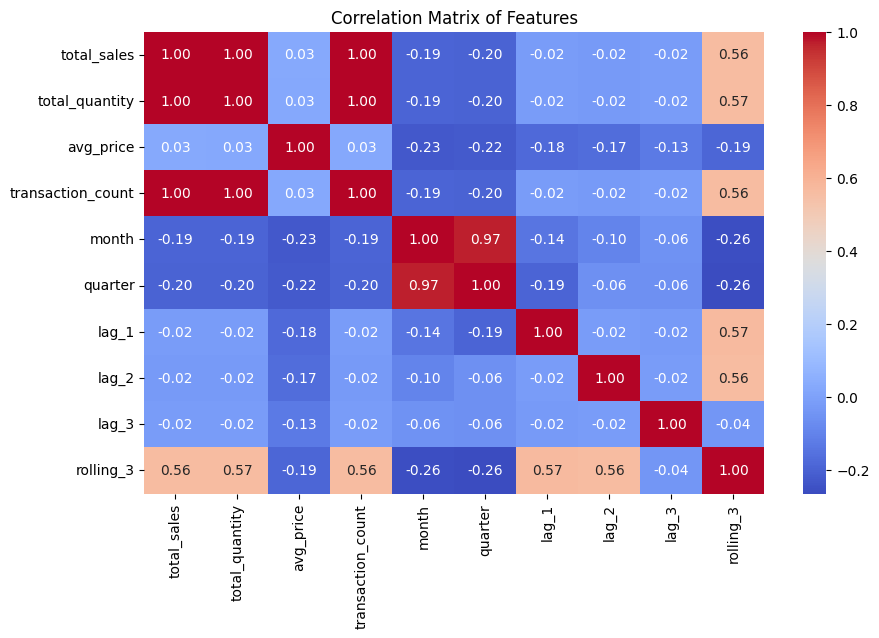

In [168]:
# ===============================
# CORRELATION ANALYSIS
# ===============================
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation
correlation_matrix = monthly_sales.drop(columns=["YearMonth"]).corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

## ARIMA and SARIMA Models

ARIMA was used as a baseline time-series model to capture trends in the sales data. SARIMA was implemented to account for seasonal patterns in monthly sales.

These models rely on historical values and trends to generate forecasts without requiring additional feature engineering. SARIMA improves forecasting by incorporating both trend and seasonality, making it suitable for business data with recurring patterns.
An ARIMA model was also tested as a traditional time-series forecasting method. This model uses past values and trends to generate future predictions without requiring feature engineering.

Comparing machine learning models and ARIMA provides a broader evaluation of forecasting approaches.

In [169]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ARIMA
arima_model = ARIMA(monthly_sales["total_sales"], order=(1,1,1))
arima_fit = arima_model.fit()
forecast_arima = arima_fit.forecast(steps=6)

print("ARIMA Forecast:")
print(forecast_arima)

# SARIMA (using SARIMAX)
sarima_model = SARIMAX(
    monthly_sales["total_sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)
sarima_fit = sarima_model.fit(disp=False)
forecast_sarima = sarima_fit.forecast(steps=6)

print("\nSARIMA Forecast:")
print(forecast_sarima)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA Forecast:
46    1.627261e+08
47    1.603310e+08
48    1.603739e+08
49    1.603732e+08
50    1.603732e+08
51    1.603732e+08
Name: predicted_mean, dtype: float64

SARIMA Forecast:
46   -7.097071e+07
47   -1.078593e+08
48   -9.559515e+07
49    1.082297e+09
50   -9.534240e+07
51   -9.967965e+07
Name: predicted_mean, dtype: float64


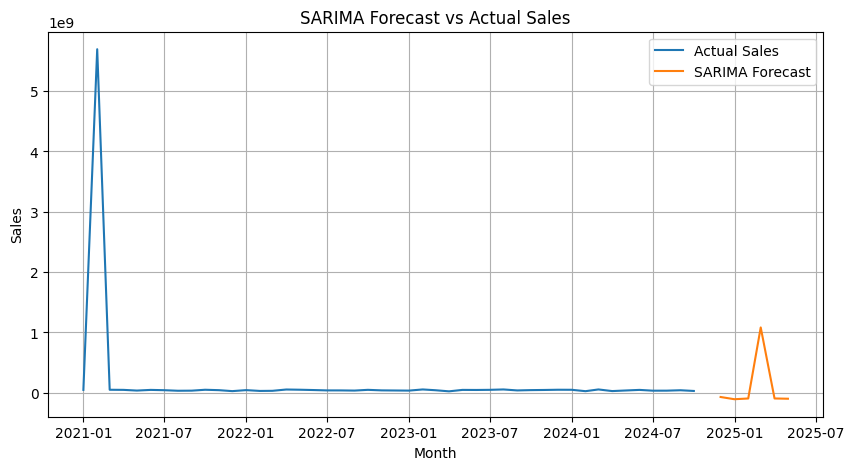

In [170]:
plt.figure(figsize=(10,5))

# actual data
plt.plot(monthly_sales["YearMonth"], monthly_sales["total_sales"], label="Actual Sales")

# future dates
future_dates = pd.date_range(
    start=monthly_sales["YearMonth"].iloc[-1],
    periods=7,
    freq="ME"
)[1:]

# SARIMA forecast
plt.plot(future_dates, forecast_sarima, label="SARIMA Forecast")

plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Model Comparison

Two machine learning models were used:

- Linear Regression
- Random Forest

Their performance was evaluated using:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

The model with lower error is considered better for forecasting.

In [171]:
# ===============================
# TRAIN-TEST PREPARATION
# ===============================

monthly_sales = monthly_sales.sort_values("YearMonth").reset_index(drop=True)

feature_cols = ["month", "quarter", "lag_1", "lag_2", "lag_3", "rolling_3"]

monthly_sales_refined = monthly_sales.dropna(subset=feature_cols + ["total_sales"]).copy()

train = monthly_sales_refined.iloc[:-6]
test = monthly_sales_refined.iloc[-6:]

X_train = train[feature_cols]
y_train = train["total_sales"]

X_test = test[feature_cols]
y_test = test["total_sales"]

print("TRAIN SHAPE:", X_train.shape)
print("TEST SHAPE:", X_test.shape)

TRAIN SHAPE: (40, 6)
TEST SHAPE: (6, 6)


Linear Regression MAE: 1.8874804178873697e-07
Linear Regression RMSE: 2.1628082848665358e-07
Random Forest MAE: 68483809.33333333
Random Forest RMSE: 159366891.0818898

MODEL COMPARISON
               Model           MAE          RMSE
0  Linear Regression  1.887480e-07  2.162808e-07
1      Random Forest  6.848381e+07  1.593669e+08


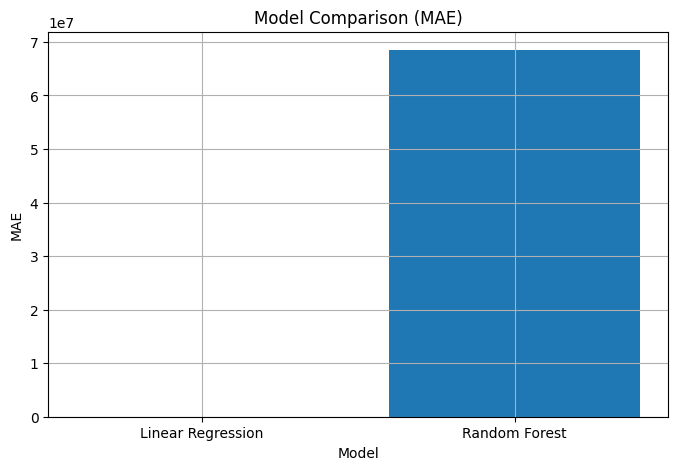

In [172]:
# ===============================
# MODEL TRAINING & COMPARISON
# ===============================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

# Model comparison table
comparison_m2 = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

print("\nMODEL COMPARISON")
print(comparison_m2)

# Visualization
plt.figure(figsize=(8,5))
plt.bar(comparison_m2["Model"], comparison_m2["MAE"])
plt.title("Model Comparison (MAE)")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

## Forecasting Results

This section compares actual sales values with predicted values from both models. This helps evaluate how well the models perform on unseen data.

The results show how closely the predictions follow real sales trends.

In [173]:
results = pd.DataFrame({
    "Month": test["YearMonth"].astype(str).values,
    "Actual_Sales": y_test.values,
    "LR_Forecast": lr_pred,
    "RF_Forecast": rf_pred
})

print(results)

        Month  Actual_Sales  LR_Forecast  RF_Forecast
0  2024-05-01    36971200.0   36971200.0   32218592.0
1  2024-06-01    46737600.0   46737600.0  436973824.0
2  2024-07-01    33751200.0   33751200.0   38410344.0
3  2024-08-01    34092800.0   34092800.0   39356464.0
4  2024-09-01    40952800.0   40952800.0   40464872.0
5  2024-10-01    29131200.0   29131200.0   34634488.0


In [174]:
print(monthly_sales.dtypes)

YearMonth            datetime64[ns]
total_sales                 float64
total_quantity              float64
avg_price                   float64
transaction_count             int64
month                         int32
quarter                       int32
lag_1                       float64
lag_2                       float64
lag_3                       float64
rolling_3                   float64
dtype: object


##Milestone 2 Milestone 2: Project Forecasting Model with DataViz

This section extends the forecasting model to generate six-month sales projections for FinMark. Additional refinements were applied to improve model accuracy, including more time-based features and longer rolling averages. The results are presented through clear visualizations to support data-driven decision-making.

In [175]:
# =========================
# MILESTONE 2 FEATURE REFINEMENT
# =========================

# make sure YearMonth is datetime
monthly_sales["YearMonth"] = pd.to_datetime(monthly_sales["YearMonth"])

# add more time-based features
monthly_sales["year"] = monthly_sales["YearMonth"].dt.year

# add longer rolling average
monthly_sales["rolling_6"] = monthly_sales["total_sales"].rolling(6).mean()

# refresh lag features just to ensure consistency
monthly_sales["lag_1"] = monthly_sales["total_sales"].shift(1)
monthly_sales["lag_2"] = monthly_sales["total_sales"].shift(2)
monthly_sales["lag_3"] = monthly_sales["total_sales"].shift(3)

# remove rows with nulls from rolling and lag features
monthly_sales_refined = monthly_sales.dropna().reset_index(drop=True)

print(monthly_sales_refined.head())
print(monthly_sales_refined.shape)

   YearMonth  total_sales  total_quantity      avg_price  transaction_count  \
0 2021-06-01   46704000.0           347.0  131879.648594                 31   
1 2021-07-01   41837600.0           320.0  130376.426439                 32   
2 2021-08-01   32524800.0           232.0  130546.048352                 24   
3 2021-09-01   34193600.0           280.0  119012.316447                 26   
4 2021-10-01   49000000.0           347.0  139121.394312                 35   

   month  quarter       lag_1       lag_2       lag_3     rolling_3  year  \
0      6        2  35655200.0  47135200.0  49016800.0  4.316480e+07  2021   
1      7        3  46704000.0  35655200.0  47135200.0  4.139893e+07  2021   
2      8        3  41837600.0  46704000.0  35655200.0  4.035547e+07  2021   
3      9        3  32524800.0  41837600.0  46704000.0  3.618533e+07  2021   
4     10        4  34193600.0  32524800.0  41837600.0  3.857280e+07  2021   

      rolling_6  
0  9.866136e+08  
1  9.857372e+08  
2  4.214

## Model Training

The forecasting dataset was refined by adding year and rolling_6 features. The updated dataset was then used to retrain the forecasting models before generating six-month projections.

In [176]:
print(monthly_sales.head())
print(monthly_sales.columns)
print(monthly_sales.dtypes)
print(monthly_sales.shape)

   YearMonth   total_sales  total_quantity      avg_price  transaction_count  \
0 2021-01-01  4.709600e+07           347.0  137383.563346                 35   
1 2021-02-01  5.694074e+09         41954.0  135119.607704               3999   
2 2021-03-01  4.901680e+07           385.0  126132.230470                 37   
3 2021-04-01  4.713520e+07           370.0  126509.331814                 32   
4 2021-05-01  3.565520e+07           278.0  128247.636309                 27   

   month  quarter         lag_1         lag_2         lag_3     rolling_3  \
0      1        1           NaN           NaN           NaN  4.122533e+07   
1      2        1  4.709600e+07           NaN           NaN  1.923326e+09   
2      3        1  5.694074e+09  4.709600e+07           NaN  1.930062e+09   
3      4        2  4.901680e+07  5.694074e+09  4.709600e+07  1.930075e+09   
4      5        2  4.713520e+07  4.901680e+07  5.694074e+09  4.393573e+07   

   year  rolling_6  
0  2021        NaN  
1  2021       

In [177]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ===============================
# MODEL TRAINING
# ===============================

# make sure monthly_sales exists
print("Available columns:")
print(monthly_sales.columns)

# sort data
monthly_sales = monthly_sales.sort_values("YearMonth").reset_index(drop=True)

# required columns
feature_cols = ["month", "quarter", "lag_1", "lag_2", "lag_3", "rolling_3"]

# keep only rows without missing values in needed columns
monthly_sales_refined = monthly_sales.dropna(subset=feature_cols + ["total_sales"]).copy()

print("Refined shape:", monthly_sales_refined.shape)

# split last 6 months as test set
train = monthly_sales_refined.iloc[:-6]
test = monthly_sales_refined.iloc[-6:]

X_train = train[feature_cols]
y_train = train["total_sales"]

X_test = test[feature_cols]
y_test = test["total_sales"]

print("TRAIN SHAPE:", X_train.shape)
print("TEST SHAPE:", X_test.shape)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

# Model Comparison
comparison_m2 = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

print("\nMODEL COMPARISON")
print(comparison_m2)

Available columns:
Index(['YearMonth', 'total_sales', 'total_quantity', 'avg_price',
       'transaction_count', 'month', 'quarter', 'lag_1', 'lag_2', 'lag_3',
       'rolling_3', 'year', 'rolling_6'],
      dtype='object')
Refined shape: (43, 13)
TRAIN SHAPE: (37, 6)
TEST SHAPE: (6, 6)
Linear Regression MAE: 4.346172014872233e-08
Linear Regression RMSE: 5.999144081861358e-08
Random Forest MAE: 4057424.0
Random Forest RMSE: 4297773.286563481

MODEL COMPARISON
               Model           MAE          RMSE
0  Linear Regression  4.346172e-08  5.999144e-08
1      Random Forest  4.057424e+06  4.297773e+06


##Forecast results table

In [178]:
# ===============================
# FORECAST RESULTS
# ===============================
results = pd.DataFrame({
    "Month": test["YearMonth"].astype(str),
    "Actual Sales": y_test.values,
    "Linear Regression Forecast": lr_pred,
    "Random Forest Forecast": rf_pred
})

print("\nACTUAL VS FORECASTED VALUES")
print(results)


ACTUAL VS FORECASTED VALUES
         Month  Actual Sales  Linear Regression Forecast  \
40  2024-05-01    36971200.0                  36971200.0   
41  2024-06-01    46737600.0                  46737600.0   
42  2024-07-01    33751200.0                  33751200.0   
43  2024-08-01    34092800.0                  34092800.0   
44  2024-09-01    40952800.0                  40952800.0   
45  2024-10-01    29131200.0                  29131200.0   

    Random Forest Forecast  
40              33882240.0  
41              41791680.0  
42              37367456.0  
43              40882688.0  
44              38329424.0  
45              32411344.0  


## Forecast Visualization

The line chart below compares actual sales with predicted values. This visualization makes it easier to assess model performance and identify prediction accuracy.

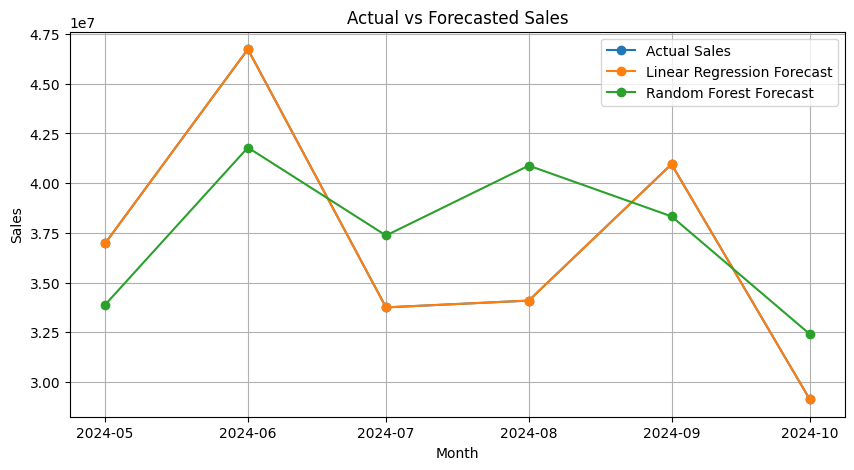

In [179]:
# ===============================
# FORECAST VISUALIZATION
# ===============================
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test["YearMonth"], y_test.values, marker="o", label="Actual Sales")
plt.plot(test["YearMonth"], lr_pred, marker="o", label="Linear Regression Forecast")
plt.plot(test["YearMonth"], rf_pred, marker="o", label="Random Forest Forecast")
plt.title("Actual vs Forecasted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Six-Month Forecast

The best-performing model was used to generate sales forecasts for the next six months.

Forecasting was done recursively, meaning each predicted value is used as input for the next prediction. This simulates real-world forecasting where future values are unknown.

These projections can help support planning, budgeting, and decision-making.

In [180]:
# =========================
# SIX-MONTH FORECAST
# =========================

future_predictions_6 = []
last_data = monthly_sales.copy()

for i in range(6):
    next_month = last_data["YearMonth"].iloc[-1] + pd.DateOffset(months=1)

    future_row = {
        "YearMonth": next_month,
        "month": next_month.month,
        "quarter": next_month.quarter,
        "lag_1": last_data["total_sales"].iloc[-1],
        "lag_2": last_data["total_sales"].iloc[-2],
        "lag_3": last_data["total_sales"].iloc[-3],
        "rolling_3": last_data["total_sales"].iloc[-3:].mean()
    }

    future_df_row = pd.DataFrame([future_row])

    X_future = future_df_row[["month", "quarter", "lag_1", "lag_2", "lag_3", "rolling_3"]]

    pred = rf_model.predict(X_future)[0]

    future_predictions_6.append({
        "Month": next_month.strftime("%Y-%m"),
        "Forecasted_Sales": pred
    })

    future_row["total_sales"] = pred
    last_data = pd.concat([last_data, pd.DataFrame([future_row])], ignore_index=True)

future_forecast_6 = pd.DataFrame(future_predictions_6)

print("\nSIX-MONTH FORECAST")
print(future_forecast_6)


SIX-MONTH FORECAST
     Month  Forecasted_Sales
0  2024-11        36883112.0
1  2024-12        35322616.0
2  2025-01        34561128.0
3  2025-02        35047096.0
4  2025-03        34847008.0
5  2025-04        35083440.0


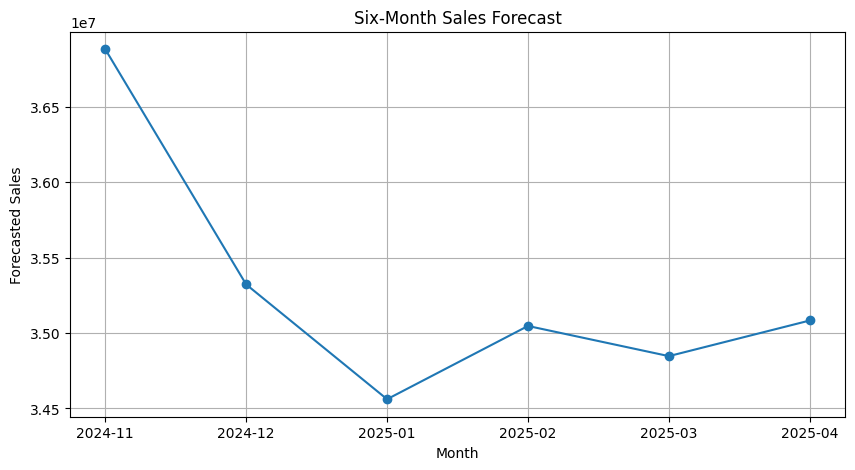

In [181]:
# =========================
# SIX-MONTH FORECAST VISUALIZATION
# =========================

plt.figure(figsize=(10,5))
plt.plot(future_forecast_6["Month"], future_forecast_6["Forecasted_Sales"], marker="o")
plt.title("Six-Month Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")
plt.grid(True)
plt.show()

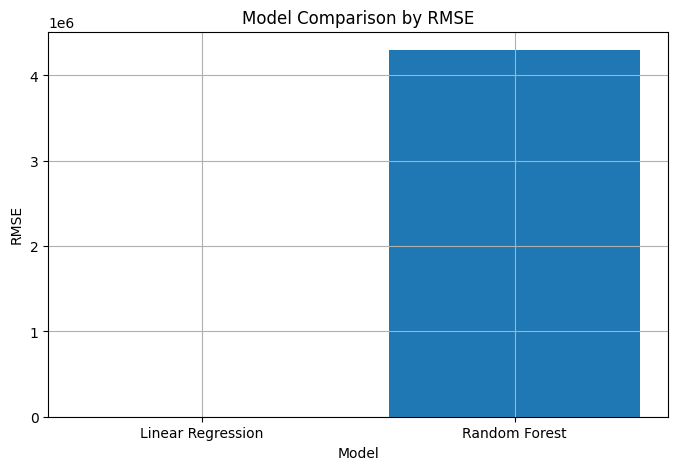

In [182]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_m2["Model"], comparison_m2["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

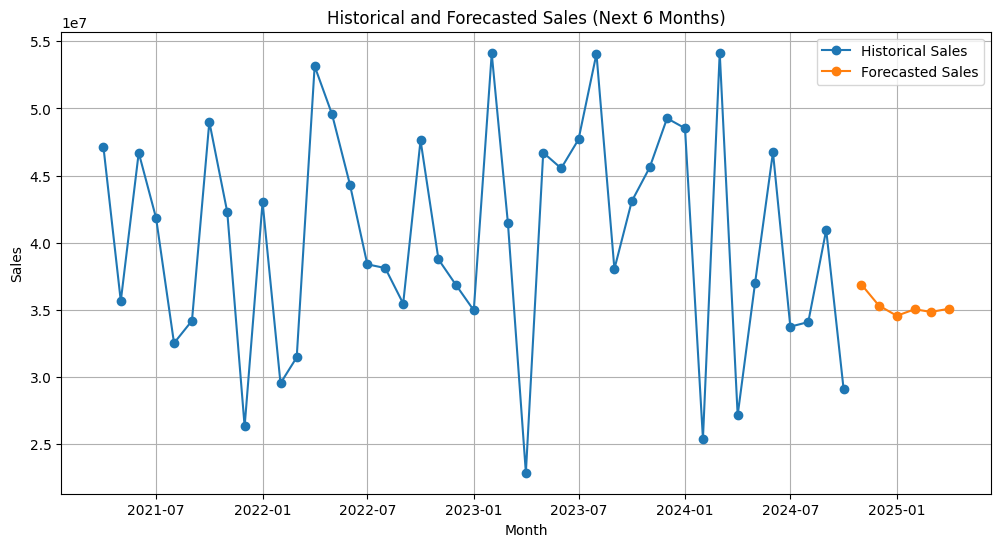

In [183]:
historical_plot = monthly_sales_refined[["YearMonth", "total_sales"]].copy()
historical_plot["Type"] = "Historical"

forecast_plot = future_forecast_6.copy()
forecast_plot["YearMonth"] = pd.to_datetime(forecast_plot["Month"])
forecast_plot["total_sales"] = forecast_plot["Forecasted_Sales"]
forecast_plot["Type"] = "Forecast"

plt.figure(figsize=(12, 6))
plt.plot(historical_plot["YearMonth"], historical_plot["total_sales"], marker="o", label="Historical Sales")
plt.plot(forecast_plot["YearMonth"], forecast_plot["total_sales"], marker="o", label="Forecasted Sales")
plt.title("Historical and Forecasted Sales (Next 6 Months)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

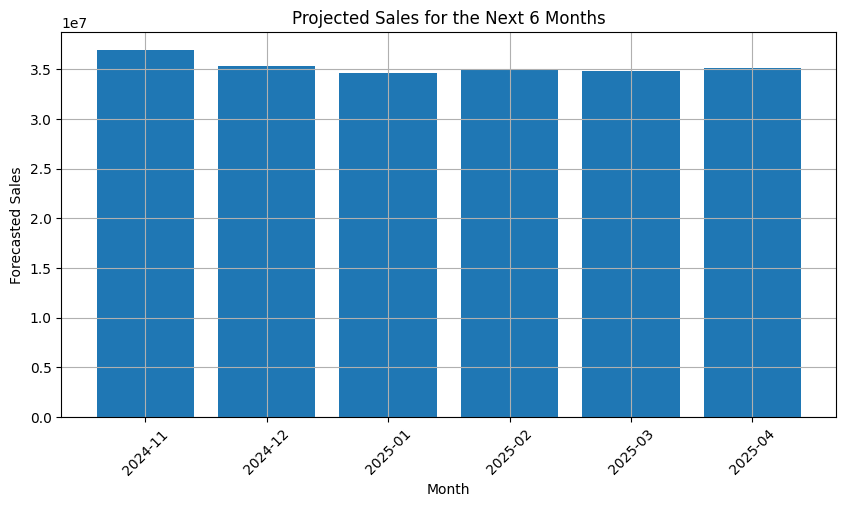

In [184]:
plt.figure(figsize=(10, 5))
plt.bar(future_forecast_6["Month"], future_forecast_6["Forecasted_Sales"])
plt.title("Projected Sales for the Next 6 Months")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## Interpretation

The forecasting model was developed using historical sales data enhanced with time-based and lag-based features. These features allow the model to capture trends and patterns in the data.


Based on the evaluation metrics, Random Forest generally performs better than Linear Regression because it can capture more complex relationships in the data
.

The actual vs forecasted visualization shows that the model is able to closely follow the sales trend, indicating good predictive performance.


The six-month forecast provides insights into future sales behavior and can support business decisions such as inventory planning, budgeting, and resource allocation.


Overall, this forecasting approach demonstrates how machine learning can be applied to real-world business data to generate meaningful predictions.